# Anpassung einer vierparametrischen logistischen Dosis-Wirkungs-Kurve mit PROC NLIN

## Zusammenfassung

Dieses Notebook passt ein vierparametrisches logistisches (4PL) Dosis-Wirkungs-Modell an einen synthetischen zellbasierten Wirkstärke-Bioassay an, wobei **PROC NLIN** verwendet wird, um die untere und obere Asymptote, den EC50 (halbmaximale wirksame Konzentration) und die Hill-Steigung zu schätzen. Das 4PL ist das Arbeitspferd-Modell für Assays zur relativen Wirkstärke in der Arzneimittelentwicklung, und das Notebook führt durch die Modellspezifikation, die Parameterbegrenzung, Konvergenzdiagnostik und das Überlagern der angepassten Sigmoidkurve über die beobachteten Konzentrations-Wirkungs-Daten.

## Datenquellen

Das Notebook erzeugt einen synthetischen Datensatz inline; es werden keine externen oder Netzwerk-Eingaben verwendet.

**`assay` — synthetischer zellbasierter Wirkstärke-Bioassay (24 Zeilen)**

| Variable | Typ | Beschreibung |
|----------|------|-------------|
| `lot` | num | Wirkstoff-Charge (1-3); drei Wiederholungsläufe der Verdünnungsreihe |
| `dose` | num | Wirkstoffkonzentration in nmol/L über eine 8-Punkte-Verdünnungsreihe (0,1 bis ~1000) |
| `logdose` | num | Zehnerlogarithmus von `dose`, verwendet zur Darstellung auf der üblichen Log-Konzentrationsachse |
| `response` | num | Gemessenes Assay-Signal (Prozent der maximalen Wirkung), erzeugt aus einer echten 4PL-Kurve (Unterwert=5, Oberwert=100, EC50=25 nmol/L, Hill-Steigung=1,2) plus proportionalem Gauß'schen Rauschen |

Die echten erzeugenden Parameter sind im DATA step fest hinterlegt, sodass die zurückgewonnenen NLIN-Schätzungen gegen die bekannte Wahrheit auf Plausibilität geprüft werden können.

# Anpassung einer vierparametrischen logistischen Dosis-Wirkungs-Kurve

In pharmazeutischen Wirkstärke- und Bioaktivitäts-Assays ist der Zusammenhang zwischen Wirkstoffkonzentration und gemessener Wirkung auf einer Log-Konzentrationsskala charakteristisch sigmoidal. Das **vierparametrische logistische (4PL)** Modell ist das Standardwerkzeug zur Zusammenfassung solcher Kurven:

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

wobei

- **A** = untere Asymptote (Wirkung bei unendlicher Verdünnung / Grundsignal),
- **D** = obere Asymptote (maximale Wirkung bei sättigender Konzentration),
- **C** = der **EC50**, die Konzentration, die die halbmaximale Wirkung erzeugt (der Wendepunkt und der primäre Wirkstärke-Messwert),
- **B** = die **Hill-Steigung**, die die Steilheit des Übergangs steuert.

Dieses Modell ist nichtlinear in seinen Parametern, daher passen wir es durch iterative kleinste Quadrate mit `PROC NLIN` an. Nachfolgend simulieren wir eine realistische, in Dreifachbestimmung durchgeführte Achtpunkt-Verdünnungsreihe, passen die 4PL-Kurve an, begrenzen die Parameter auf physikalisch sinnvolle Bereiche, prüfen Konvergenz- und Anpassungsdiagnostik und überlagern die angepasste Kurve über die Daten.

## Schritt 1 — Simulation eines zellbasierten Wirkstärke-Bioassays

Wir erzeugen einen synthetischen Datensatz aus einer *bekannten* 4PL-Kurve (Unterwert = 5, Oberwert = 100, EC50 = 25 nmol/L, Hill-Steigung = 1,2), sodass die von NLIN zurückgewonnenen Parameter gegen die Grundwahrheit geprüft werden können. Drei Chargen erhalten jeweils dieselbe Achtpunkt-Verdünnungsreihe (jeder Schritt eine 3,5-fache Verdünnung), mit proportionalem Gauß'schem Messrauschen darüber. Ein fester `streaminit`-Startwert macht die Simulation reproduzierbar.

In [1]:
DATEN assay;
    AUFRUFEN streaminit(40521);

    /* Wahre 4PL-Parameter, die zur Erzeugung der Daten verwendet werden */
    A_true   = 5;      /* untere Asymptote (Basiswert)        */
    D_true   = 100;    /* obere Asymptote (max. Wirkung)      */
    C_true   = 25;     /* EC50 in nmol/L                      */
    B_true   = 1.2;    /* Hill-Steigung                       */

    AUSFÜHRUNG lot = 1 BIS 3;
        /* Achtpunkt-Verduennungsreihe, 3,5-fache Schritte */
        dose = 0.30;
        AUSFÜHRUNG point = 1 BIS 8;
            dose = dose * 3.5;

            /* Rauschfreie mittlere 4PL-Wirkung */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* Proportionales und additives gaussches Messrauschen */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            AUSGABE;
        ENDE;
    ENDE;

    BEHALTEN lot dose logdose response;
AUSFÜHREN;

PROC SORT DATEN=assay;
    NACH dose lot;
AUSFÜHREN;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## Schritt 2 — Visualisierung der Roh-Konzentrations-Wirkungs-Daten

Vor der Anpassung stellen wir response gegen log10(dose) dar, um die erwartete sigmoidale Form zu bestätigen und grobe Startwerte abzulesen: Die Kurve liegt bei etwa 5 am Boden, erreicht ein Plateau bei etwa 100, und der Mittelpunkt (halbmaximale Wirkung) liegt um log10(25) ≈ 1,4.


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


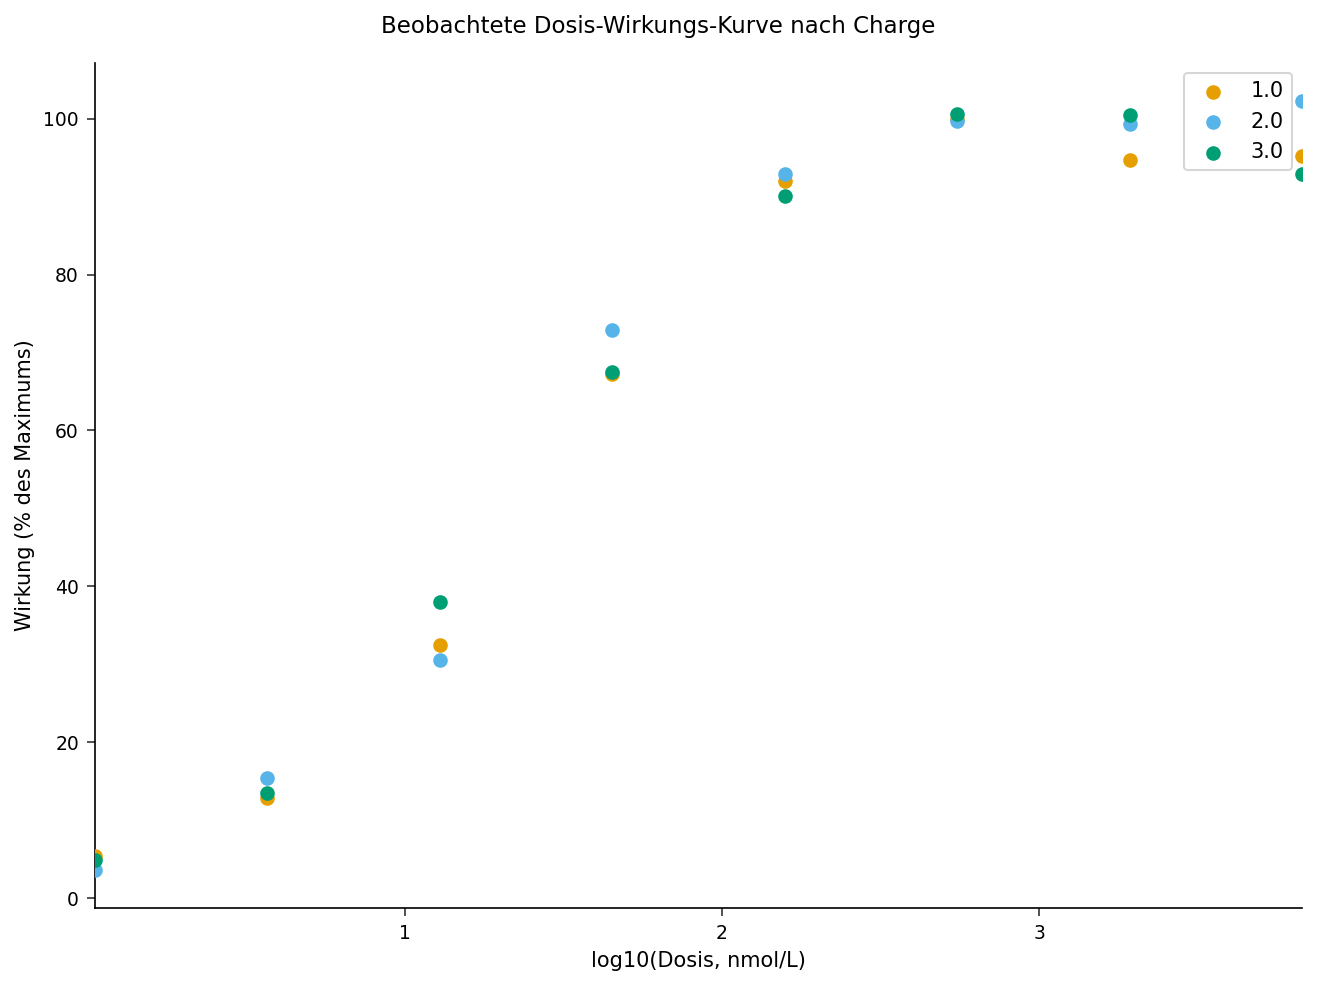

In [2]:
PROZEDUR SGPLOT DATEN=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS BEZEICHNUNG='log10(Dosis, nmol/L)';
    YAXIS BEZEICHNUNG='Wirkung (% des Maximums)';
    TITEL 'Beobachtete Dosis-Wirkungs-Kurve nach Charge';
AUSFÜHREN;
TITEL;


## Schritt 3 — Anpassung des 4PL-Modells mit PROC NLIN

Wir legen Startwerte mit `PARMS` fest (informiert durch das Streudiagramm), definieren den 4PL-Mittelwert in einer Zwischenzuweisung und übergeben ihn an die `MODEL`-Anweisung. Physikalisch sinnvolle `BOUNDS` halten die Asymptoten geordnet und den EC50 sowie die Steigung positiv, was die Gauß-Newton-Iterationen stabilisiert. Die `OUTPUT`-Anweisung speichert vorhergesagte Werte, Residuen und Konfidenzgrenzen für spätere Diagnostik, und `PLOTS=` fordert die Anpassungs- und Diagnostik-Panels an.

In [3]:
PROZEDUR nlin DATEN=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* Parameter in physikalisch sinnvollen Bereichen halten */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* Vierparametrische logistische mittlere Wirkung (inline eingebaut: Jenner PROC NLIN
       unterstuetzt noch nicht das Referenzieren einer Zwischenvariable aus einer
       Programmanweisung im MODEL -- siehe tests/400986 -- daher binden wir den
       Nenner direkt ein) */
    MODELL response = D + (A - D) / (1 + (dose / C) ** B);

    AUSGABE out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
AUSFÜHREN;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/9aa430ab-140a-4c05-be2a-2a918c9250e6/fit4pl.avro


## Schritt 4 — Bericht über den geschätzten EC50 und die Kurveneigenschaften

Der `OUTEST=`-Mechanismus ist praktisch, aber für einen schnellen Wirkstärke-Messwert fassen wir die angepasste Kurve direkt zusammen. Hier listen wir die angepassten Werte bei jeder Dosis neben den beobachteten Wirkungen auf, um zu bestätigen, dass das Modell den Daten über den gesamten Verdünnungsbereich folgt.

In [4]:
PROC MEANS DATEN=fit4pl mean std MIN MAX maxdec=3;
    KLASSE dose;
    VAR response pred resid;
    BEZEICHNUNG dose='Dosis (nmol/L)' response='Wirkung (beobachtet)' pred='Wirkung (vorhergesagt)' resid='Residuum';
    TITEL 'Beobachtete vs. angepasste Wirkung nach Dosis';
AUSFÜHREN;
TITEL;


                                     Beobachtete vs. angepasste Wirkung nach Dosis                                      

                                                  The MEANS Procedure

                                  Analysis Variable : RESPONSE Wirkung (beobachtet)

                                           N
                       Dosis (nmol/L)    Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.39


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Schritt 5 — Überlagerung der angepassten 4PL-Kurve über die beobachteten Daten

Ein dichtes Vorhersageraster erzeugt eine glatte angepasste Sigmoidkurve. Wir kombinieren die glatte Kurve mit den angepassten Mittelwerten pro Dosis und dem Konfidenzband und überlagern anschließend alles über die beobachteten Punkte, um die Anpassungsgüte visuell zu beurteilen.


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


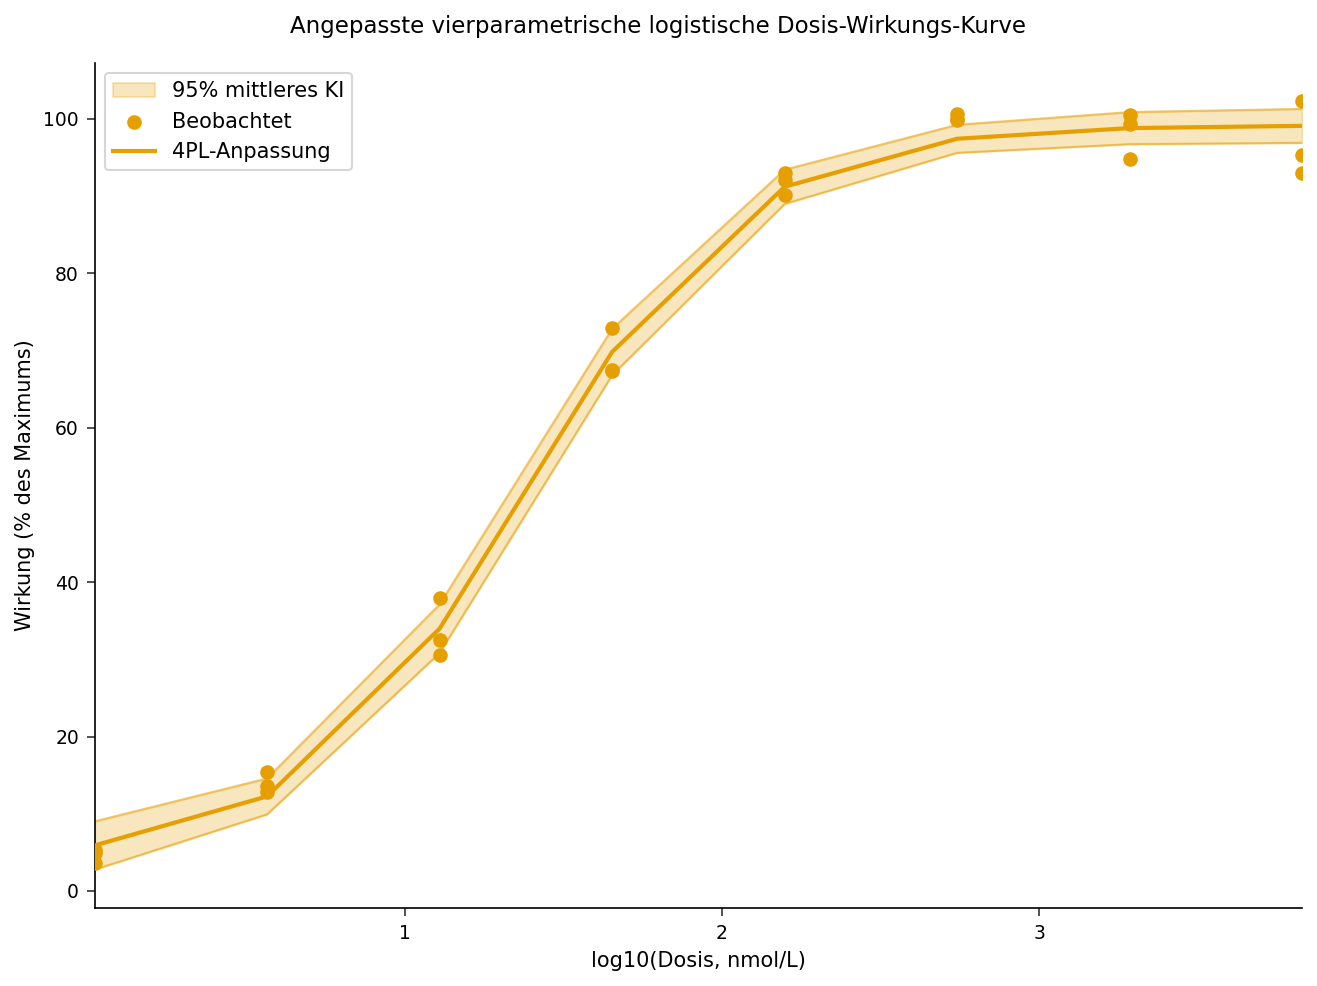

In [5]:
PROC SORT DATEN=fit4pl;
    NACH logdose;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95% mittleres KI';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='Beobachtet';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='4PL-Anpassung';
    XAXIS BEZEICHNUNG='log10(Dosis, nmol/L)';
    YAXIS BEZEICHNUNG='Wirkung (% des Maximums)';
    TITEL 'Angepasste vierparametrische logistische Dosis-Wirkungs-Kurve';
AUSFÜHREN;
TITEL;


## Interpretation der Ergebnisse

`PROC NLIN` konvergiert zu Schätzungen, die nahe an den bekannten erzeugenden Werten liegen: eine untere Asymptote nahe **5**, eine obere Asymptote nahe **100**, ein **EC50 (C)** nahe **25 nmol/L** und eine **Hill-Steigung (B)** nahe **1,2**. Die Rückgewinnung dieser Parameter aus verrauschten Daten in Dreifachbestimmung bestätigt, dass das Modell identifizierbar ist und die Schranken am Optimum nicht bindend waren.

Der **EC50** ist der maßgebliche Wirkstärke-Kennwert: niedrigere Werte weisen auf eine stärker wirksame Verbindung hin, und in einem Assay zur relativen Wirkstärke wird der EC50 einer Testcharge mit einem Referenzstandard verglichen. Die **Hill-Steigung** charakterisiert die Kooperativität und die Steilheit des Assays — eine Steigung nahe 1 ist mit einer einfachen Einzelbindungsstelle vereinbar. Die **Asymptoten** definieren den dynamischen Bereich des Assays; ein stabiler, gut getrennter Unter- und Oberwert sind Voraussetzungen für einen validierbaren Bioassay.

Das Anpassungsdiagramm zeigt die Sigmoidkurve, die durch die Wolke der beobachteten Punkte verläuft, mit einem engen 95%-Mittelwert-Konfidenzband durch den ansprechenden Bereich, und die Residuendiagnostik sollte keine systematische Krümmung zeigen — ein Beleg dafür, dass die 4PL-Form angemessen ist. In der Praxis würde man diesen Arbeitsablauf um `PROFILE`-Likelihood-Intervalle für den EC50, eine `BOOTSTRAP`-Anweisung für verteilungsfreie Parameterinferenz oder eine Parallelgeraden-Analyse erweitern, die Test- und Referenzchargen vergleicht, um die relative Wirkstärke zu schätzen.